In [2]:
!pip install pybamm

Defaulting to user installation because normal site-packages is not writeable


In [4]:
pip install --upgrade --force-reinstall backports


Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement backports (from versions: none)
ERROR: No matching distribution found for backports
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade --force-reinstall setuptools jaraco.context


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.2 MB/s eta 0:00:00:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 74.0.0
    Uninstalling setuptools-74.0.0:
      Successfully uninstalled setuptools-74.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 5.4.1 requires pyqt5<5.16, which is not installed.
spyder 5.4.1 requires pyqtwebengine<5.16, which is not installed.
conda-repo-cli 1.0.27 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.27 requires nbformat==5.4.0, but you have nbformat 5.7.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install --upgrade --force-reinstall pybtex


Defaulting to user installation because normal site-packages is not writeable
  Using cached pybtex-0.24.0-py2.py3-none-any.whl (561 kB)
  Using cached six-1.16.0-py2.py3-none-any.whl (11 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.2/751.2 kB 3.4 MB/s eta 0:00:0000:01
  Attempting uninstall: latexcodec
    Found existing installation: latexcodec 2.0.1
    Uninstalling latexcodec-2.0.1:
      Successfully uninstalled latexcodec-2.0.1
  Attempting uninstall: pybtex
    Found existing installation: pybtex 0.24.0
    Uninstalling pybtex-0.24.0:
      Successfully uninstalled pybtex-0.24.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.27 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.27 requires nbformat==5.4.0, but you have nbformat 5.7.0 which is incompatible.
conda-repo-cli 1.0.27 requires

In [2]:
# from run_code import run_battery_simulation

# # Example usage
# a_nmc, b_nmc, c_nmc, d_nmc = 153.1353114622245, -299.5867812542784, 182.0307751506729, -65.20873735054764 #uniform for overall diffusion if fine, but what about individual a, b, c, d; gaussian for the overall diffusion  (biggist SD informed by the literature)
# my_graphite_diff_parameter = 1 #gaussian is good for figuring out the diffusion - but what if mean if 4 SDs away - is a uniform prior betteR? Could just do a big SD. (SD: 10^-3? Something big that is informed by literature) 
# sep_por, neg_por, pos_por = 0.4, 0.25, 0.335 #uniform for porosity is fine; between 20 and 45 percent for porosities; 5 percent error (do we even need to ); 
# cap_dl_neg = 0.2 #Will depend on particle size, particle size distributiosn are Gaussian; (SD: averasge value about 10 or 15 microns - a SD might be 5 microns for particle sizes themselves) (so 0.2 mean and 0.1 SD) 

# #lectrode capacity and stoichiometry variables? Tune the stoichiometric operating window 
# #to figure out the initial state of charge 


# #don't go above 1.5C current  - could even do 2 C

# p1 = 0.5  # fraction of C-rate - 0.1 to 2 limit uniform - initial discharge amplitude
# p2 = 598.6 # discharge duration - seconds - make sure this is duration of current discharge  - specify as a function of p1 to be between 2% and 10%SOC - change more than 2% of the SOC
# p3 = 1800/2  # rest after discharge -  30 minutes in seconds - max 30 minutes, minimum 100 seconds
# p4 = 1.0 # HPPC amplitude - fraction of C-rate - HPPC - 0.1 to 2 limit uniform
# p5 = 10.0 # HPPC duration - seconds - 1 to 20 seconds 
# p6 = 600  # Rest between HPPCs- 10 minutes in seconds - min 10 seconds max 600 seconds 

# p7 = 10e-3 #start_frequency - maybe uniform between 1e-3 to 10e-3?
# p8 = 3000 #end_time - quarter of a period of p7 to full period of p7

# # Run the simulation
# time_data, terminal_voltage_data = run_battery_simulation(a_nmc, b_nmc, c_nmc, d_nmc, my_graphite_diff_parameter, sep_por, neg_por, pos_por, cap_dl_neg, p1, p2, p3, p4, p5, p6, p7, p8)


In [ ]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
import os
from datetime import datetime

def single_run(params):
    # Unpack your parameters here
    #a_nmc, b_nmc, c_nmc, d_nmc, diff_param, sep_por, neg_por, pos_por, cap_dl_neg, p1, p2, p3, p4, p5, p6, p7, p8 = params
    
    # Run the simulation with the given parameters
    #time_data, voltage_data = run_battery_simulation(a_nmc, b_nmc, c_nmc, d_nmc, diff_param, sep_por, neg_por, pos_por, cap_dl_neg, p1, p2, p3, p4, p5, p6, p7, p8)
    time_data, current_data, voltage_data = run_battery_simulation(*params)
    return params, time_data, current_data, voltage_data

def generate_parameters():
    from scipy.stats import multivariate_normal, norm
    
    sigma = np.array([[ 414.16743966, -439.53022219,  157.53082159,  -36.59908635], \
            [-439.53022219,  475.21734538, -170.37237657,   41.13810463], \
            [ 157.53082159, -170.37237657,   61.12237867,  -14.75655731], \
            [ -36.59908635,   41.13810463,  -14.75655731,    3.8372772 ]])
    mu = np.array([-2.29714210e+01, -1.23599647e-02, -1.09287243e+00,  1.62538939e+00])
    a_nmc, b_nmc, c_nmc, d_nmc = multivariate_normal.rvs(mu,sigma,size=1)
    # graphite_diff_parameter posterior from inference
    stdev = np.sqrt(3.62066527e-05)
    mu = 1.
    graphite_diff_parameter = norm.rvs(mu, stdev, size=1)[0]
    # sep_por, neg_por, pos_por
    lb = 0.2
    ub = 0.45
    sep_por = np.random.uniform(lb,ub)
    neg_por = np.random.uniform(lb,ub)
    pos_por = np.random.uniform(lb,ub)
    
    # cap_dl_neg
    mu = 0.2
    stdev = 0.05
    cap_dl_neg = norm.rvs(mu, stdev, size=1)[0]
    # p1
    lb = 0.1
    ub=2.
    p1 = np.random.uniform(lb,ub)
    
    # p2 
    lb = 72./p1
    ub = 360./p1
    p2 = np.random.uniform(lb,ub)
    
    #     # p3
    lb = 100.
    ub = 1800.
    p3 = np.random.uniform(lb,ub)
    
    #     # p4
    lb = 0.1
    ub = 2
    p4 = np.random.uniform(lb,ub)
    
     # p5
    lb = 1.
    ub = 20
    p5 = np.random.uniform(lb,ub)
    
    #     # p6
    lb = 10.
    ub = 600.
    p6 = np.random.uniform(lb,ub)
    
     # p7
    lb = 0.001
    ub = 0.0095
    p7 = np.random.uniform(lb,ub)
    
  # p8
    lb = 0.25/p7
    ub = 1/p7
    p8 = np.random.uniform(lb,ub)
    
    

    return (a_nmc, b_nmc, c_nmc, d_nmc,graphite_diff_parameter,sep_por,neg_por,pos_por,cap_dl_neg,p1,p2,p3,p4,p5,p6,p7,p8)

def generate_parameters_sample_priors():
    from scipy.stats import multivariate_normal, norm
    
    sigma = np.array([[ 414.16743966, -439.53022219,  157.53082159,  -36.59908635], \
            [-439.53022219,  475.21734538, -170.37237657,   41.13810463], \
            [ 157.53082159, -170.37237657,   61.12237867,  -14.75655731], \
            [ -36.59908635,   41.13810463,  -14.75655731,    3.8372772 ]])
    mu = np.array([-2.29714210e+01, -1.23599647e-02, -1.09287243e+00,  1.62538939e+00])
    a_nmc, b_nmc, c_nmc, d_nmc = multivariate_normal.rvs(mu,sigma,size=1)
    # graphite_diff_parameter posterior from inference
    stdev = np.sqrt(3.62066527e-05)
    mu = 1.
    graphite_diff_parameter = norm.rvs(mu, stdev, size=1)[0]
    # sep_por, neg_por, pos_por
    lb = 0.2
    ub = 0.45
    sep_por = np.random.uniform(lb,ub)
    neg_por = np.random.uniform(lb,ub)
    pos_por = np.random.uniform(lb,ub)
    
    # cap_dl_neg
    mu = 0.2
    stdev = 0.05
    cap_dl_neg = norm.rvs(mu, stdev, size=1)[0]
    # p1
    lb = 0.1
    ub=2.
    p1 = np.random.uniform(lb,ub)
    
    # p2 
    lb = 72./p1
    ub = 360./p1
    p2 = np.random.uniform(lb,ub)
    
    #     # p3
    lb = 100.
    ub = 1800.
    p3 = np.random.uniform(lb,ub)
    
    #     # p4
    lb = 0.1
    ub = 2
    p4 = np.random.uniform(lb,ub)
    
     # p5
    lb = 1.
    ub = 20
    p5 = np.random.uniform(lb,ub)
    
    #     # p6
    lb = 10.
    ub = 600.
    p6 = np.random.uniform(lb,ub)
    
     # p7 initial chirp frequency 
    lb = 0.001
    ub = 0.0095
    p7 = np.random.uniform(lb,ub)
    
  # p8
    lb = 1/p7
    ub = 4/p7
    p8 = np.random.uniform(lb,ub)
    
    

    return (a_nmc, b_nmc, c_nmc, d_nmc,graphite_diff_parameter,sep_por,neg_por,pos_por,cap_dl_neg,1,180,1000,1,10,300,0.05,100)

def save_results(params,time_data, current_data, voltage_data, run_id,results_dir):
    # Define your directory for saving results
    #results_dir = "sep19_2024_sim_data_fft_testing_3xp8"
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Save the time data and voltage data as .npy files
    # Save the parameters, time data, and voltage data as .npy files
    np.save(os.path.join(results_dir, f"params_{run_id}.npy"), params)
    np.save(os.path.join(results_dir, f"time_data_{run_id}.npy"), time_data)
    np.save(os.path.join(results_dir, f"current_data_{run_id}.npy"), current_data)

    
    np.save(os.path.join(results_dir, f"voltage_data_{run_id}.npy"), voltage_data)
    # np.save(os.path.join(results_dir, f"time_data_{run_id}.npy"), time_data)
    # np.save(os.path.join(results_dir, f"voltage_data_{run_id}.npy"), voltage_data)

if __name__ == "__main__":
    
    results_dir = input("Please enter the folder name for saving results: ").strip()
    
    # If the user doesn't provide a folder name, use a default one
    if not results_dir:
        results_dir = "default_results_folder"
    
    user_input = input("Do you want to enable chirp? (y/n): ").strip().lower()
    chirp = user_input == "y"

    
    if(chirp):
        from run_code import run_battery_simulation
    else:
        from run_code_no_chirp import run_battery_simulation
    
    #number_of_data_generated = 1000 #change this to change number of data generated
    number_of_data_generated = int(input("Enter the number of data points to generate: ").strip())

    user_input_2 = input("Do you want a variable design? (y/n): ").strip().lower()
    var_design = user_input_2 == "y"
    if(var_design):
        parameter_sets = [generate_parameters() for _ in range(number_of_data_generated)]
    else:
        parameter_sets = [generate_parameters_sample_priors() for _ in range(number_of_data_generated)]
    
    #print(parameter_sets)
    
    dynamic_number_of_workers = os.cpu_count() - 1 #can remove -1, just here to keep one core free
    print("Number of cores being used", dynamic_number_of_workers)
    with ProcessPoolExecutor(max_workers=dynamic_number_of_workers) as executor:
        for i, (params, time_data, current_data, voltage_data) in enumerate(executor.map(single_run, parameter_sets)):
            current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")  # Date and time format
            run_id = f"{current_datetime}_{i}"
            save_results(params,time_data, current_data, voltage_data, run_id,results_dir)
            print(f"Run {i} completed and saved.")

    #print(len(time_data))        
"""
DEsign parameter definitions -> gm
p1 = 0.5  # fraction of C-rate - 0.1 to 2 limit uniform - initial discharge amplitude
p2 = 598.6 # discharge duration - seconds - make sure this is duration of current discharge  - specify as a function of p1 to be between 2% and 10%SOC - change more than 2% of the SOC
p3 = 1800/2  # rest after discharge -  30 minutes in seconds - max 30 minutes, minimum 100 seconds
p4 = 1.0 # HPPC amplitude - fraction of C-rate - HPPC - 0.1 to 2 limit uniform
p5 = 10.0 # HPPC duration - seconds - 1 to 20 seconds 
p6 = 600  # Rest between HPPCs- 10 minutes in seconds - min 10 seconds max 600 seconds 

p7 = 10e-3 #start_frequency - maybe uniform between 1e-3 to 10e-3?
p8 = 3000 #end_time - quarter of a period of p7 to full period of p7
"""

Please enter the folder name for saving results:  simulation_no_chirp_changing_current_cse_598_part_2
Do you want to enable chirp? (y/n):  n


In [ ]:
print(np.max(np.diff(time_data)))

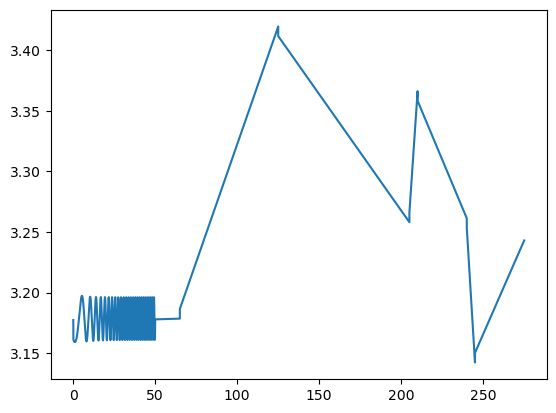

In [18]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(time_data[0:2515],voltage_data[0:2515])

In [6]:
len(time_data)

12575